In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from IPython.display import display
from astropy.coordinates import SkyCoord
import astropy.units as u

In [2]:
# Define column names based on the header in the SRL file
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

In [3]:
spw = [
       2,
       3 , 
       4, 
       5, 
       6, 
       8, 
       15, 
       16, 
       17
       ]

In [4]:
srl_file_paths = []
dataframes = []

for s in spw:
    paths = [
        f'../paper1/23/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/25/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/32/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/36/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl'
    ]
    srl_file_paths.append(paths)
    
    spw_data = []
    for path in paths:
        try:
            df = pd.read_csv(path, delim_whitespace=True, comment='#', names=column_names)
            spw_data.append(df)
        except FileNotFoundError:
            print(f"File not found: {path}")
    
    if spw_data:
        combined_df = pd.concat(spw_data, ignore_index=True)
        dataframes.append(combined_df)

# Optionally, check the content of dataframes
print(f"Total dataframes read: {len(dataframes)}")

File not found: ../paper1/32/spw2-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw3-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw4-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw5-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw6-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw8-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw15-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw16-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw17-2.5arcsec-nit5000--awproject.pybdsf.srl
Total dataframes read: 9


/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_99869/2154577651.py:10: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw[i]}', alpha=0.7, edgecolors='w', s=50, marker=marker, color=color)


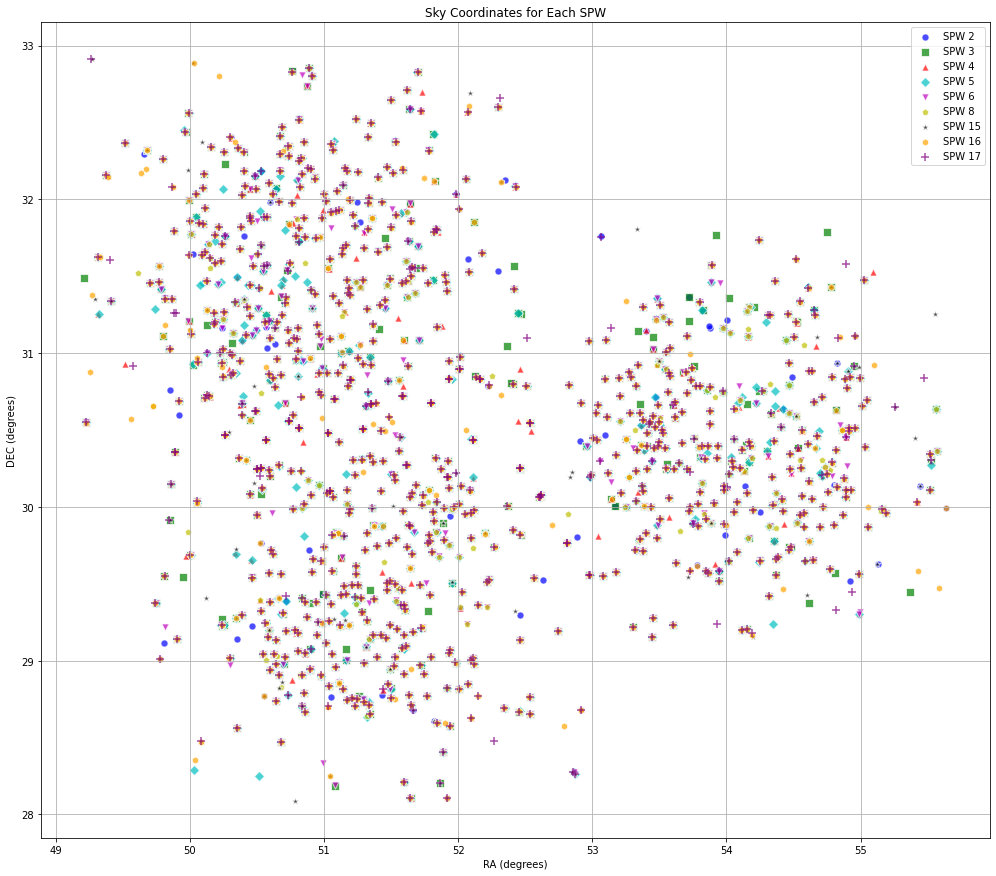

In [5]:
# Define markers and colors for different SPWs
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '+']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple']

# Plotting RA and DEC using SkyCoord
plt.figure(figsize=(17, 15))
for i, (df, marker, color) in enumerate(zip(dataframes, markers, colors)):
    # Convert RA and DEC to SkyCoord
    coords = SkyCoord(ra=df['RA'].values * u.degree, dec=df['DEC'].values * u.degree, frame='icrs')
    plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw[i]}', alpha=0.7, edgecolors='w', s=50, marker=marker, color=color)

plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.title('Sky Coordinates for Each SPW')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# Identify repeated sources in each SPW dataframe
repeated_sources = []

for i, df in enumerate(dataframes):
    # Round RA and DEC to two decimal places
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    
    # Group by rounded RA and DEC to find duplicates
    duplicated = df[df.duplicated(subset=['RA_rounded', 'DEC_rounded'], keep=False)]
    repeated_sources.append(duplicated)
    
    print(f"Repeated sources in SPW {spw[i]}:")
    print(duplicated[['RA', 'DEC']])

Repeated sources in SPW 2:
            RA        DEC
6    52.131666  30.846564
7    52.108900  30.439661
25   51.797663  30.678908
47   51.568591  30.452521
67   51.351060  30.666784
79   51.286313  30.508112
108  51.082122  30.701877
116  51.032581  30.479172
194  50.502193  30.249614
195  50.529649  30.251753
234  50.261914  30.466262
290  52.981298  29.558829
293  52.810541  29.765993
296  52.609133  30.062300
307  52.462741  30.249586
316  52.133407  30.845471
319  52.112076  30.438030
356  51.797923  30.678326
392  51.570171  30.451036
420  51.347413  30.667149
431  51.288366  30.507556
462  51.077422  30.703097
474  51.031838  30.479501
527  50.531087  30.251416
528  50.503099  30.248851
539  50.262598  30.466033
800  52.978692  29.560359
804  52.808577  29.767772
805  52.607077  30.063120
808  52.461602  30.250997
Repeated sources in SPW 3:
            RA        DEC
6    52.107641  30.439645
10   52.009326  30.897448
23   51.797310  30.678335
45   51.588700  30.723438
63   51.42

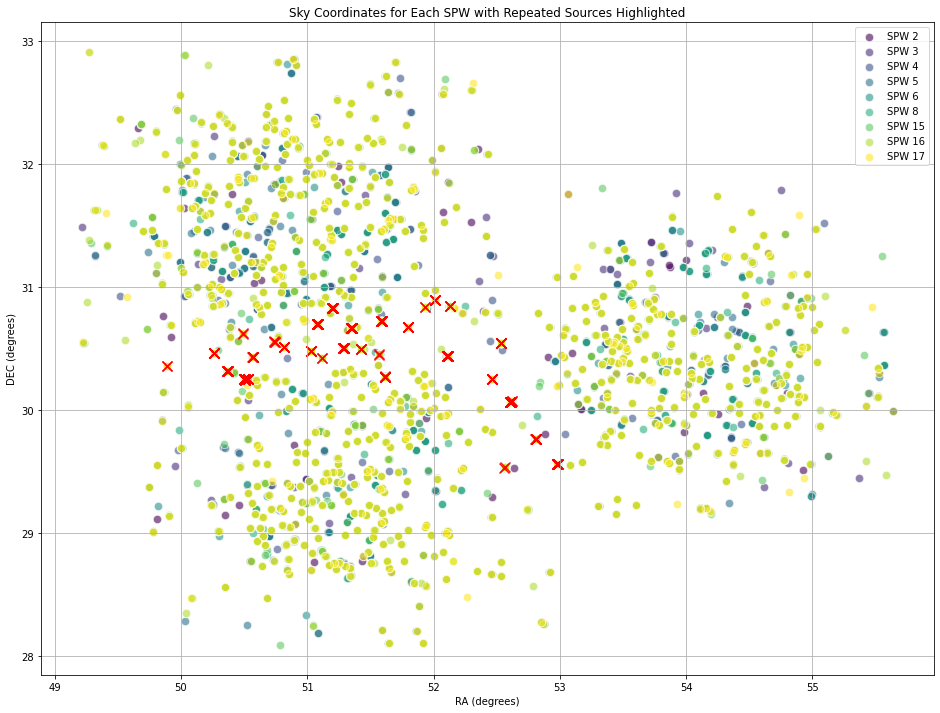

In [7]:
# Define a colormap
cmap = plt.get_cmap('viridis', len(spw))

# Create a figure for plotting
plt.figure(figsize=(16, 12))

# Initialize a list to store repeated sources
repeated_sources = []

# Plot original data points
for i, (df, spw_value) in enumerate(zip(dataframes, spw)):
    # Round RA and DEC to two decimal places
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    
    # Group by rounded RA and DEC to find duplicates
    duplicated = df[df.duplicated(subset=['RA_rounded', 'DEC_rounded'], keep=False)]
    repeated_sources.append((spw_value, duplicated))
    
    # Convert RA and DEC to SkyCoord
    coords = SkyCoord(ra=df['RA'].values * u.degree, dec=df['DEC'].values * u.degree, frame='icrs')
    plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw_value}', alpha=0.6, edgecolors='w', s=70, color=cmap(i), marker='o')

# Plot repeated sources
for spw_value, df in repeated_sources:
    if not df.empty:
        coords = SkyCoord(ra=df['RA'].values * u.degree, dec=df['DEC'].values * u.degree, frame='icrs')
        plt.scatter(coords.ra.deg, coords.dec.deg, alpha=0.9, s=100, color='red', marker='x')

# Final plot adjustments
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.title('Sky Coordinates for Each SPW with Repeated Sources Highlighted')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
for i, df in enumerate(dataframes):
    # Round RA and DEC to two decimal places for identifying duplicates
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    
    # Print the shape before replacement
    print(f"Shape of DataFrame for SPW {spw[i]} before replacement: {df.shape}")
    
    duplicated = df[df.duplicated(subset=['RA_rounded', 'DEC_rounded'], keep=False)]
    if not duplicated.empty:
        # Print the duplicates before replacement
        print(f"Repeated sources in SPW {spw[i]} before replacement:")
        print(duplicated[['RA', 'DEC', 'E_Total_flux']])
        
        # Keep the source with the smallest 'E_Total_flux'
        df = df.loc[df.groupby(['RA_rounded', 'DEC_rounded'])['E_Total_flux'].idxmin()]
        
        # Print the dataframe after replacement
        print(f"DataFrame for SPW {spw[i]} after replacement:")
        print(df[['RA', 'DEC', 'E_Total_flux']])
    
    dataframes[i] = df  # Update the dataframe
    
    # Print the shape after replacement
    print(f"Shape of DataFrame for SPW {spw[i]} after replacement: {df.shape}")
    
    # Save the updated dataframe to a CSV file
    df.to_csv(f'../paper1/csv/spw{spw[i]}.csv', index=False)

print("Replacement process completed and updated dataframes saved to CSV files.")

Shape of DataFrame for SPW 2 before replacement: (811, 47)
Repeated sources in SPW 2 before replacement:
            RA        DEC  E_Total_flux
6    52.131666  30.846564      0.000601
7    52.108900  30.439661      0.000330
25   51.797663  30.678908      0.000312
47   51.568591  30.452521      0.000220
67   51.351060  30.666784      0.000305
79   51.286313  30.508112      0.000254
108  51.082122  30.701877      0.000357
116  51.032581  30.479172      0.000228
194  50.502193  30.249614      0.000275
195  50.529649  30.251753      0.000322
234  50.261914  30.466262      0.000493
290  52.981298  29.558829      0.000564
293  52.810541  29.765993      0.000331
296  52.609133  30.062300      0.000536
307  52.462741  30.249586      0.000492
316  52.133407  30.845471      0.000739
319  52.112076  30.438030      0.000340
356  51.797923  30.678326      0.000269
392  51.570171  30.451036      0.000288
420  51.347413  30.667149      0.000263
431  51.288366  30.507556      0.000378
462  51.077422 

722  52.460964  30.252983      0.000362
DataFrame for SPW 15 after replacement:
            RA        DEC  E_Total_flux
253  49.228849  30.549028      0.000244
251  49.267739  32.910372      0.000331
252  49.290457  31.354635      0.000695
250  49.314669  31.625498      0.000757
249  49.377771  32.157383      0.000506
..         ...        ...           ...
518  55.408752  30.446385      0.000323
517  55.443948  30.137932      0.000230
516  55.515505  30.110569      0.000298
515  55.519809  30.344239      0.000356
514  55.553197  31.254253      0.000432

[704 rows x 3 columns]
Shape of DataFrame for SPW 15 after replacement: (704, 47)
Shape of DataFrame for SPW 16 before replacement: (756, 47)
Repeated sources in SPW 16 before replacement:
            RA        DEC  E_Total_flux
7    52.111783  30.437797      0.000325
14   52.009904  30.897069      0.000560
27   51.798193  30.678007      0.000290
37   51.615701  30.272711      0.000377
63   51.350884  30.666407      0.000431
75   51.28

In [39]:
updated_dataframes = []

for s in spw:
    df = pd.read_csv(f'../paper1/csv/spw{s}.csv')
    
    updated_dataframes.append(df)
    print(f"Shape of DataFrame for SPW {s} after reading from CSV: {df.shape}")

print("Reading process completed.")

Shape of DataFrame for SPW 2 after reading from CSV: (796, 47)
Shape of DataFrame for SPW 3 after reading from CSV: (837, 47)
Shape of DataFrame for SPW 4 after reading from CSV: (857, 47)
Shape of DataFrame for SPW 5 after reading from CSV: (858, 47)
Shape of DataFrame for SPW 6 after reading from CSV: (802, 47)
Shape of DataFrame for SPW 8 after reading from CSV: (718, 47)
Shape of DataFrame for SPW 15 after reading from CSV: (704, 47)
Shape of DataFrame for SPW 16 after reading from CSV: (738, 47)
Shape of DataFrame for SPW 17 after reading from CSV: (741, 47)
Reading process completed.


In [40]:
# Columns of interest with errors
loc_columns = ['RA', 'E_RA', 'DEC', 'E_DEC']
flux_columns = ['Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'Isl_rms']

In [41]:
processed_dataframes = []

for df in updated_dataframes:
    # Select the columns of interest
    selected_columns = df[loc_columns + flux_columns].copy()
    
    # Multiply the relevant columns by 1e3 to convert to mJy
    selected_columns[flux_columns] = selected_columns[flux_columns] * 1e3
    
    # Append the processed dataframe to the list
    processed_dataframes.append(selected_columns)

# Print the processed dataframes for verification
for i, df in enumerate(processed_dataframes):
    print(f"Processed DataFrame for SPW {spw[i]}:")
    print(df.head())

# Optionally, save the processed dataframes to new CSV files
for i, df in enumerate(processed_dataframes):
    df.to_csv(f'../paper1/csv/processed_spw{spw[i]}.csv', index=False)

print("Processing and saving completed.")

Processed DataFrame for SPW 2:
          RA      E_RA        DEC     E_DEC  Total_flux  E_Total_flux  \
0  49.224625  0.001085  30.551550  0.000980    1.020448      0.273464   
1  49.314738  0.000708  31.625586  0.000400    2.736404      0.426115   
2  49.378700  0.000448  32.156396  0.000344    3.437603      0.386189   
3  49.414960  0.000787  31.339343  0.000674    1.806365      0.476657   
4  49.516106  0.000428  32.369276  0.000257    4.733774      0.388752   

   Peak_flux  E_Peak_flux   Isl_rms  
0   0.770304     0.127535  0.124990  
1   2.217461     0.207822  0.206709  
2   2.704725     0.186853  0.181686  
3   1.795388     0.272608  0.273867  
4   3.295637     0.170345  0.167509  
Processed DataFrame for SPW 3:
          RA      E_RA        DEC     E_DEC  Total_flux  E_Total_flux  \
0  49.212225  0.000696  31.490769  0.000534    0.649660      0.199167   
1  49.227428  0.000977  30.549461  0.000625    0.951494      0.240368   
2  49.315997  0.000564  31.625165  0.000388    3.031

In [42]:
rename_dict = {
    'RA': r'\text{RA}',
    'E_RA': r'$\sigma_{\text{RA}}$',
    'DEC': r'\text{DEC}',
    'E_DEC': r'$\sigma_{\text{DEC}}$',
    'Total_flux': r'$S_{\text{total}}$',
    'E_Total_flux': r'$\sigma_{S_{\text{total}}}$',
    'Peak_flux': r'$S_{\text{peak}}$',
    'E_Peak_flux': r'$\sigma_{S_{\text{peak}}}$',
    'Isl_rms':r'$RMS$'
}

In [43]:
for i, df in enumerate(processed_dataframes):
    # Rename the columns for LaTeX table
    df.rename(columns=rename_dict, inplace=True)
    
    num_chunks = (len(df) // rows_per_chunk) + 1
    
    for chunk_index in range(num_chunks):
        start_row = chunk_index * rows_per_chunk
        end_row = start_row + rows_per_chunk
        chunk_df = df.iloc[start_row:end_row]
        
        # Convert the dataframe chunk to a LaTeX table using to_latex from DataFrame
        latex_table = chunk_df.style.hide(axis='index').to_latex(hrules=True)
        
        # Save the LaTeX table to a .tex file
        with open(f'../paper1/csv/latex/spw{spw[i]}_part{chunk_index + 1}.tex', 'w') as file:
            file.write(latex_table)

print("Processing and saving to LaTeX longtables completed.")

Processing and saving to LaTeX longtables completed.
